# Notebook to test and see the implementation of Hierarchical Refinement algorithm in jax

In [47]:
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from ott.geometry import pointcloud
from ott.problems.linear import linear_problem
from ott.solvers.linear import sinkhorn_lr

In [20]:
def create_points(
    rng= jax.random.key(0),       # seed for randomeness
    n: int = 100,       # number of points for X and Y
    d: int = 2,         # dimension vectors in X and Y
    ):
    """
    By default we use uniform distribution for a and b.
    """
    rngs = jax.random.split(rng, 4)
    x = jax.random.normal(rngs[0], (n, d)) + 10
    y = jax.random.normal(rngs[1], (n, d))
    a = jax.random.uniform(rngs[2], (n,))
    b = jax.random.uniform(rngs[3], (n,))
    a = a / jnp.sum(a)
    b = b / jnp.sum(b)
    return x, y, a, b

In [23]:
def solve_low_rank_ot(
    x,                  # points in X
    y,                  # points in Y 
    a,                  # weights for X   
    b,                  # weights for Y   
    epsilon=0.1,        # regularization parameter@
    rank=2):            # rank of the low-rank approximation

    # définition of the geometry
    # we use the squared euclidean distance
    geom = pointcloud.PointCloud(x, y, epsilon=epsilon)

    # we use the weights a and b to define the cost
    ot_prob = linear_problem.LinearProblem(geom, a, b)

    # we use the low-rank solver
    solver = sinkhorn_lr.LRSinkhorn(rank=rank)

    # we use the low-rank solver
    ot_lr = solver(ot_prob)
    return ot_lr

In [49]:
def hierarchical_refinement(
    x,
    y,
    a,
    b,
    min_size=1,
    epsilon=0.1,
    rank=2,
    verbose: bool = False
    ):

    def split_equally(arr, q_or_r):
        """Split the array into two equal parts according to the max score."""
        scores = jnp.max(q_or_r, axis=1)
        sorted_idx = jnp.argsort(scores)
        n = len(arr)
        return arr[sorted_idx[:n // 2]], arr[sorted_idx[n // 2:]]
    
    def split_weights(weights, q_or_r):
        """Same splitting for the weights, renormalized."""
        scores = jnp.max(q_or_r, axis=1)
        sorted_idx = jnp.argsort(scores)
        n = len(weights)
        w1 = weights[sorted_idx[:n // 2]]
        w2 = weights[sorted_idx[n // 2:]]
        w1 = w1 / jnp.sum(w1)
        w2 = w2 / jnp.sum(w2)
        return w1, w2
    t = 0 

    # Initialisation des clusters
    # à t = 0, il s'agit de X et Y et de leurs poids
    clusters_to_refine = [(x, y, a, b)]

    # Initialisation de la liste des clusters finaux
    # qui contiendra les couples de clusters
    final_matches = []

    # On itère jusqu'à ce que tous les clusters soient de taille <= min_size
    while any(len(xi) > min_size or len(yi) > min_size for xi, yi, _, _ in clusters_to_refine):
        s = time.time()
        n = len(clusters_to_refine)    
        # On incrémente le compteur de temps
        t += 1

        new_clusters = []       # variables pour stocker les nouveaux clusters

        for x_curr, y_curr, a_curr, b_curr in clusters_to_refine:
            if len(x_curr) <= min_size and len(y_curr) <= min_size:
                final_matches.append((x_curr, y_curr))
                continue

            ot_lr = solve_low_rank_ot(x_curr, y_curr, a_curr, b_curr, epsilon=epsilon, rank=rank)
            
            x1, x2 = split_equally(x_curr, ot_lr.q)
            y1, y2 = split_equally(y_curr, ot_lr.r)
            a1, a2 = split_weights(a_curr, ot_lr.q)
            b1, b2 = split_weights(b_curr, ot_lr.r)

            new_clusters.append((x1, y1, a1, b1))
            new_clusters.append((x2, y2, a2, b2))

        clusters_to_refine = new_clusters
        delta = round(time.time() - s,1)

        if verbose:
            print(f"Iteration {t} - {delta} s. : {len(clusters_to_refine)} to refine / Final matches so far: {len(final_matches)}")

    # Tous les clusters restants sont de taille <= min_size
    final_matches.extend(clusters_to_refine)

    if verbose:
        print(f"Final matches: {len(final_matches)} clusters")

    return final_matches


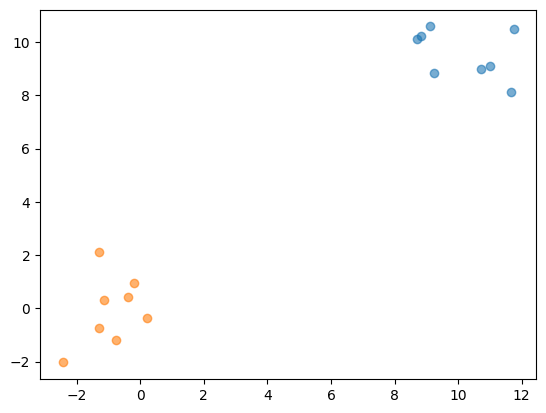

In [67]:
x, y, a, b = create_points( n=8, d=2)

c_src1 = "#1f77b4"   # bleu foncé
c_tgt1 = "#aec7e8"   # bleu clair

c_src2 = "#ff7f0e"   # orange foncé
c_tgt2 = "#ffbb78"   # orange clair


plt.scatter(x[:, 0], x[:, 1], color=c_src1, label="Source_1", alpha=0.6)
plt.scatter(y[:, 0], y[:, 1], color=c_src2, label="Source_2", alpha=0.6)

#plt.scatter(y1[:, 0], y1[:, 1], color=c_tgt1, label="Target_1", alpha=0.6)
#plt.scatter(y2[:, 0], y2[:, 1], color=c_tgt2, label="Target_2", alpha=0.6)

plt.show()

In [68]:
clusters = hierarchical_refinement(x, y, a, b, min_size=1, epsilon=0.1, rank=2, verbose=True)

Iteration 1 - 0.4 s. : 2 to refine / Final matches so far: 0
Iteration 2 - 0.6 s. : 4 to refine / Final matches so far: 0
Iteration 3 - 1.1 s. : 8 to refine / Final matches so far: 0
Final matches: 8 clusters


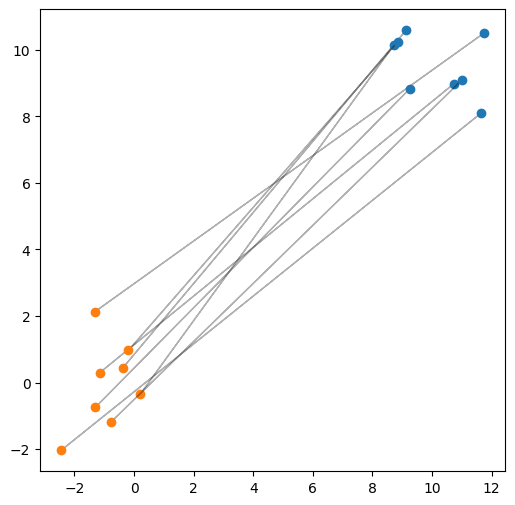

In [70]:
plt.figure(figsize=(6,6))
for pair in clusters:
    x, y, d, _ = pair
    plt.arrow(x[0][0], x[0][1],
            y[0][0] - x[0][0],
            y[0][1] - x[0][1],
            head_width=0.05, alpha=0.3, length_includes_head=True)
    plt.scatter(x[0,0], x[0,1], c='C0', label='Source')
    plt.scatter(y[0,0], y[0,1], c='C1', label='Target')

plt.show()